In [2]:
# imports
import os
import pandas as pd
import numpy as np
import json
import random 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
from TrackReconstruction_functions import *
import sys
from io import StringIO


In [26]:
file = "/mnt/d/events_full_range/simulated_data/nodiff/events_full_range_nexus_324_7975749.h5"
diffusion = "nodiff"
pressure = 1
event_type = "events_full_range"
eid = 65002

part_df = pd.read_hdf(file, "MC/particles")
hits_df = pd.read_hdf(file, "MC/hits")

part_df.head()

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,65000,2,e-,1,0,665.281738,842.478088,-1665.907227,0.000000,643.231689,...,0.328781,0.675132,-0.818303,0.0,0.0,-0.0,0.711556,938.433655,none,eIoni
1,65000,117,e-,0,2,643.086182,866.584961,-1972.093384,3.867634,643.101868,...,-0.036469,0.037664,-0.033002,-0.0,-0.0,0.0,0.003741,0.099286,eIoni,eIoni
2,65000,118,e-,0,117,643.091492,866.599915,-1972.124146,3.868613,643.086060,...,-0.022504,0.008112,-0.027252,0.0,-0.0,-0.0,0.001285,0.080658,eIoni,eIoni
3,65000,116,e-,0,2,643.086182,866.584961,-1972.093384,3.867634,643.085083,...,-0.006643,-0.001583,-0.000490,-0.0,0.0,0.0,0.000046,0.001135,eIoni,msc
4,65000,115,e-,0,2,643.086182,866.584961,-1972.093384,3.867634,643.086731,...,0.002501,-0.003721,0.001737,0.0,-0.0,0.0,0.000023,0.001933,eIoni,eIoni


In [27]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

### True Data

In [28]:
#-----GET VERTEX------
def get_vertex(part, eid):

    x_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_x.iloc[0]
    y_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_y.iloc[0]
    z_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_z.iloc[0]

    return x_vertex, y_vertex, z_vertex

In [29]:
vertex = get_vertex(part_df, eid)
print(vertex)

(np.float32(-317.4299), np.float32(1771.9365), np.float32(2171.1467))


In [30]:
def get_true_angle(part, eid):
    p_x1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_x.iloc[0]
    p_y1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_y.iloc[0]
    p_z1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_z.iloc[0]
    
    p_x2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_x.iloc[0]
    p_y2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_y.iloc[0]
    p_z2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_z.iloc[0]
    
    cos12 = ((p_x1 * p_x2) + (p_y1 * p_y2) + (p_z1 * p_z2))/(np.sqrt((p_x1 ** 2) + (p_y1 ** 2) + (p_z1 ** 2)) * np.sqrt((p_x2 ** 2) + (p_y2 ** 2) + (p_z2 ** 2)))
    return cos12

In [31]:
cos12_true = get_true_angle(part_df, eid)
print(cos12_true)

-0.15268166


In [32]:
def get_true_e_vectors(eid, part_df, vertex, particle_ids=[1,2]):
    vertex = np.array(vertex, dtype=float)
    
    vectors=[]

    for pid in particle_ids:
        row = part_df[(part_df.event_id==eid) & (part_df.particle_id==pid)].iloc[0]

        p = np.array([row.initial_momentum_x, row.initial_momentum_y, row.initial_momentum_z], dtype=float)

        #unit dir
        direction = p / np.linalg.norm(p)

        endpoint = vertex + direction

        vectors.append((endpoint, direction))

    vectors = [
        {"endpoint": vec[0].tolist(), "direction": vec[1].tolist()}
        for vec in vectors
        ]

    return vectors

In [33]:
vectors = get_true_e_vectors(eid, part_df, vertex)
print(vectors)

[{'endpoint': [-316.53896018236304, 1771.718813207967, 2171.5452589362585], 'direction': [0.890940940683822, -0.21771022953286787, 0.39853042063332184]}, {'endpoint': [-317.2200807442596, 1771.7423330837476, 2170.188466800249], 'direction': [0.20982037878732304, -0.19419035375243748, -0.9582617153758399]}]


/tmp/ipykernel_3152/3743787252.py:42: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(15, 5))


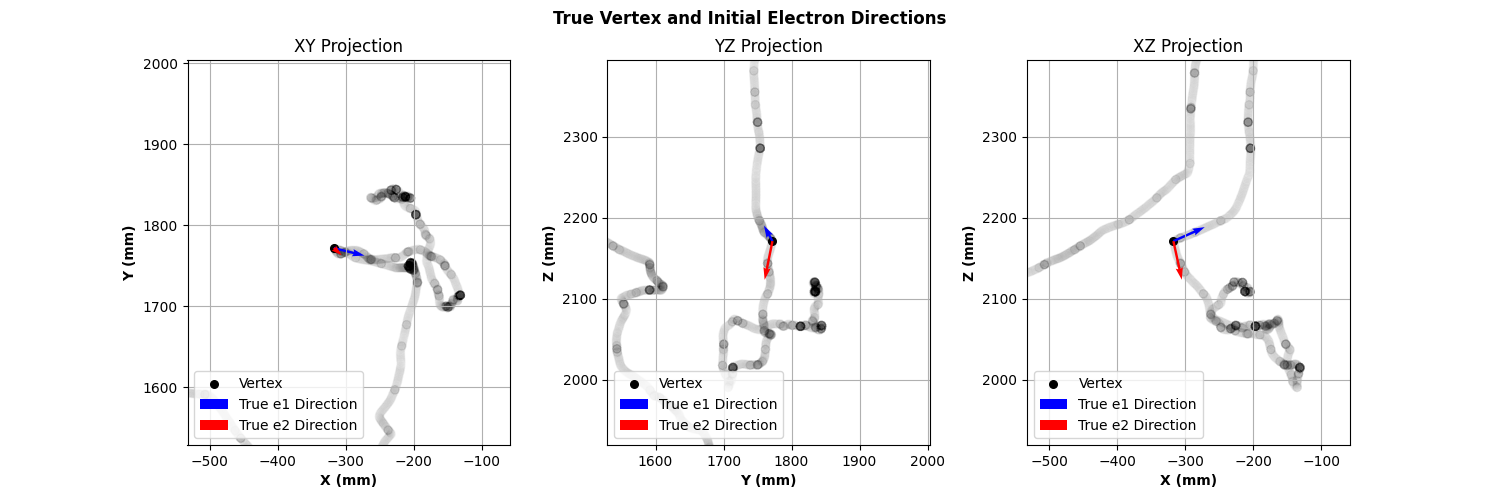

In [80]:
# plot true
%matplotlib widget
x_vertex, y_vertex, z_vertex = vertex[0], vertex[1], vertex[2]
p1, p2 = vectors[0]["direction"], vectors[1]["direction"]

scale_factor = 50  # Adjust this to make arrows longer or shorter

p1 = [scale_factor * comp for comp in p1]
p2 = [scale_factor * comp for comp in p2]


event_hits = hits_df[hits_df.event_id == eid].copy()
if diffusion != "nodiff":
    event_hits["z"] = event_hits["z"]-z_shift

indices = np.arange(len(event_hits))

# getting axis range
    
xs = [x_vertex, x_vertex + p1[0], x_vertex + p2[0]]
ys = [y_vertex, y_vertex + p1[1], y_vertex + p2[1]]
zs = [z_vertex, z_vertex + p1[2], z_vertex + p2[2]]


#min/max
xmin, xmax = min(xs), max(xs)
ymin, ymax = min(ys), max(ys)
zmin, zmax = min(zs), max(zs)

#ranges = and padded
max_range = max(xmax-xmin, ymax-ymin, zmax-zmin)
pad = max_range * 3

xmid = (xmax + xmin) / 2 
ymid = (ymax + ymin) / 2
zmid = (zmax + zmin) / 2

xlims = (xmid - max_range/2 - pad, xmid + max_range/2 + pad)
ylims = (ymid - max_range/2 - pad, ymid + max_range/2 + pad)
zlims = (zmid - max_range/2 - pad, zmid + max_range/2 + pad)

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

#XY projection
ax1.scatter(x_vertex, y_vertex, color = "black", s=30, label="Vertex")
ax1.scatter(event_hits.x, event_hits.y, alpha=0.01, c=event_hits.energy, cmap="Greys_r")
ax1.quiver(x_vertex, y_vertex, p1[0], p1[1], color="blue", label="True e1 Direction", scale_units="xy", scale=1)
ax1.quiver(x_vertex, y_vertex, p2[0], p2[1], color="red", label="True e2 Direction", scale_units="xy", scale=1)
ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax1.set_xlabel("X (mm)", fontweight="bold")
ax1.set_ylabel("Y (mm)", fontweight="bold")
ax1.set_title("XY Projection")
ax1.legend(loc="lower left")
ax1.grid(True)
    
#YZ projection
ax2.scatter(y_vertex, z_vertex, color = "black", s=30, label="Vertex")
ax2.scatter(event_hits.y, event_hits.z, alpha=0.01, c=event_hits.energy, cmap="Greys_r")
ax2.quiver(y_vertex, z_vertex, p1[1], p1[2], color="blue", label="True e1 Direction", scale_units="xy", scale=1)
ax2.quiver(y_vertex, z_vertex, p2[1], p2[2], color="red", label="True e2 Direction", scale_units="xy", scale=1)
ax2.set_xlim(ylims)
ax2.set_ylim(zlims)
ax2.set_xlabel("Y (mm)", fontweight="bold")
ax2.set_ylabel("Z (mm)", fontweight="bold")
ax2.set_title("YZ Projection")
ax2.legend(loc="lower left")
ax2.grid(True)

#XZ projection
ax3.scatter(x_vertex, z_vertex, color = "black", s=30, label="Vertex")
ax3.scatter(event_hits.x, event_hits.z, alpha=0.01, c=event_hits.energy, cmap="Greys_r")
ax3.quiver(x_vertex, z_vertex, p1[0], p1[2], color="blue", label="True e1 Direction", scale_units="xy", scale=1)
ax3.quiver(x_vertex, z_vertex, p2[0], p2[2], color="red", label="True e2 Direction", scale_units="xy", scale=1)
ax3.set_xlim(xlims)
ax3.set_ylim(zlims)
ax3.set_xlabel("X (mm)", fontweight="bold")
ax3.set_ylabel("Z (mm)", fontweight="bold")
ax3.set_title("XZ Projection")
ax3.legend(loc="lower left")
ax3.grid(True)

fig.suptitle(f"True Vertex and Initial Electron Directions", fontweight="bold")
plt.subplots_adjust(wspace=0.3)
plt.show()

### Reco Data (From True Vertex)

In [43]:
def get_node_centers_df(hits_df, eid, pressure, diffusion):
    #print(f"diffusion: {diffusion}")
    #print(f"pressure: {pressure}")
    data = hits_df[hits_df["event_id"] == int(eid)].copy()
    if np.isnan(data.z.mean()) or data.z.empty:
        print(f"Skipping event {eid} because hits are missing or invalid")
        return pd.DataFrame()
    #print(pressure, type(pressure))
    #print(diffusion, type(diffusion))
    Diff_smear, energy_threshold, diff_scale_factor, radius_sf, group_sf, Tortuosity_dist, voxel_size, det_size  = InitializeParams(pressure, diffusion)
    # voxel_sf=1.1
    # energy_threshold=0
    # energy_threshold = 0.0004
    #diff_scale_factor = diff_scale_change
    """
    print("Diffussion smear is: ",        Diff_smear,            "mm/sqrt(cm)")
    print("Energy threshold is: ",        1000*energy_threshold, "keV")
    print("diffision scale factor is: ",  diff_scale_factor)
    print("Radius scale factor is: ",     radius_sf)
    print("Hit grouping factor is: ",     group_sf)
    print("Tortuosity distance scale is:", Tortuosity_dist)
    print("The voxel size is:",           voxel_size)
    print("The det_size is", det_size)
    """
    #print(f"diffusion: {diffusion}")
    if (diffusion == "next1t"):
        mean_sigma=6
    elif (diffusion == "nodiff"):
        #print(f"check diffusion: {diffusion}")
        mean_sigma=10/np.sqrt(pressure)
        #print(f"check mean sigma: {mean_sigma}")
    else:
        if data.z.mean() < 0:
            print("skipping event, invalid data.z.mean()")
            return None, None
        mean_sigma = diff_scale_factor*Diff_smear*np.sqrt(0.1*data.z.mean())

    # The expected diffusion is less than vox size so replace
    if (mean_sigma < 1.5*voxel_size):
        mean_sigma = 1.5*voxel_size
    
    # Create the bins ---- 
    xbw  = mean_sigma
    xmin = -det_size - mean_sigma/2 
    xmax = det_size  + mean_sigma/2
    
    ybw  = mean_sigma
    ymin = -det_size - mean_sigma/2 
    ymax = det_size  + mean_sigma/2
    
    # This shifts the z pos of the events so 0 is at anode
    # can set this to zero
    #z_shift = det_size
    z_shift = 0
    
    zbw=mean_sigma
    zmin=-det_size + z_shift - mean_sigma/2 
    zmax=det_size + z_shift + mean_sigma/2

    # bins for x, y, z
    xbins = np.arange(xmin, xmax+xbw, xbw)
    ybins = np.arange(ymin, ymax+ybw, ybw)
    zbins = np.arange(zmin, zmax+zbw, zbw)
    
    # center bins for x, y, z
    xbin_c = xbins[:-1] + xbw / 2
    ybin_c = ybins[:-1] + ybw / 2
    zbin_c = zbins[:-1] + zbw / 2

    # If there are overlapping voxels, merge them. Otherwise the energy gets messed up
    data = (data.groupby(["event_id", "x", "y", "z"], as_index=False)["energy"].sum())
    # then sort it based on the x,y,z
    data = data.sort_values(by=['x', "y", "z"]).reset_index(drop=True)
    """
    print(f"xmin: {xmin}, xmax: {xmax}, xbw: {xbw}")
    print(f"ymin: {ymin}, ymax: {ymax}, ybw: {ybw}")
    print(f"zmin: {zmin}, zmax: {zmax}, zbw: {zbw}")
    
    print(f"data x range: {data['x'].min()} to {data['x'].max()}")
    print(f"data y range: {data['y'].min()} to {data['y'].max()}")
    print(f"data z range: {data['z'].min()} to {data['z'].max()}")
    """
    # Apply grouping
    data_copy = data.copy()
    #df_merged = CutandRedistibuteEnergy(data_copy, energy_threshold)
    print("applied grouping")

    
    
    if diffusion == "next1t":
        mean_sigma_group = 10
    elif (diffusion == "nodiff"):
        #print(f"diffusion: {diffusion}")
        mean_sigma_group=15
    else:
        mean_sigma_group = group_sf*Diff_smear*np.sqrt(0.1*data.z.mean())

    if (mean_sigma_group < voxel_size/2.0):
        mean_sigma_group = voxel_size/2.0
        """
    print("Mean sigma group", mean_sigma_group)
    print("Number of hits:", len(data))
    print("Mean z:", data.z.mean(), " diffusion = ", mean_sigma)
    print("Mean Sigma: ", mean_sigma)
    """
    print("Mean sigma group:", mean_sigma_group)

    
    df_merged = GroupHits(data_copy, mean_sigma_group)
    #print(f"df_merged: {df_merged.group_id.unique()}")
    # Apply clustering
    node_centers_df = []
    energy_gid_dict = {}
    for gid in sorted(df_merged.group_id.unique()):
        #print(f"applying clustering for {gid}")
        temp_df = df_merged[df_merged.group_id == gid]
        energy_sum = temp_df["energy"].sum()
        energy_gid_dict[gid] = energy_sum
        temp_df.reset_index(drop=True, inplace=True)
        node_centers_df.append(Cluster(temp_df, mean_sigma))
    max_energy_gid = max(energy_gid_dict, key=energy_gid_dict.get)
    node_centers_df = pd.concat(node_centers_df, ignore_index=True)
    node_centers_df = node_centers_df[node_centers_df.group_id == max_energy_gid]
    #print("COMPLETED NODE CENTERS DF")
    return node_centers_df


In [64]:
def clip_to_bounds(x, y, z, xlims, ylims, zlims):
    x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
    mask = (
        (x >= xlims[0]) & (x <= xlims[1]) &
        (y >= ylims[0]) & (y <= ylims[1]) &
        (z >= zlims[0]) & (z <= zlims[1])
    )
    return x[mask], y[mask], z[mask]

In [78]:
def get_reco_e_vectors(hits_df, part_df, eid, N, diffusion, pressure, z_shift, vertex=None, plot=False, smeared=False):

    node_centers_df = get_node_centers_df(hits_df, eid, pressure, diffusion)
    df = node_centers_df.copy() 
    if diffusion != "nodiff":
        df["z"] = df["z"] - z_shift
        print("Subtracted z shift")
    
    if vertex is None:
        vertex = get_vertex(part_df, eid)
    else:
        vertex = vertex

    
    hits = df[["x", "y", "z"]].values

    
    dists = np.linalg.norm(hits - vertex, axis=1)
    closest_hits = hits[np.argsort(dists)[:N]] # sort by dist
    hits_from_vertex = closest_hits - vertex # use vertex as reference
    radii = np.linalg.norm(hits_from_vertex, axis=1)

    # keep only hits that are not at the vertex
    mask = radii > 15 #events <15mm from vertex are not used
    hits_from_vertex = hits_from_vertex[mask]
    closest_hits = closest_hits[mask]
    radii = radii[mask]

    if len(radii)<2:
        print("Not enough hits to cluster")
        return[]
    # normalize
    directions = hits_from_vertex / radii[:, None]
    
    kmeans = KMeans(n_clusters=2, random_state=0).fit(directions) # 2 clusters
    labels = kmeans.labels_
    
    vectors = []
    for cluster_id in [0,1]:
        cluster_hits = closest_hits[labels == cluster_id] #cluster hits
    
        if len(cluster_hits) == 0:
            print("Not enough hits")
            continue
            
        #get vectors
        dists = np.linalg.norm(cluster_hits - vertex, axis=1) 
        endpoint = cluster_hits[np.argmin(dists)]
        direction_vector = endpoint - vertex
        vectors.append((endpoint, direction_vector))

    event_hits = hits_df[hits_df.event_id == eid]

    # plot clustered hits
    if plot == True:
        vertex_true = get_vertex(part_df, eid)
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")
        part_1 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 1)]
        part_2 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 2)]
    
        p1 = part_1[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()
        p2 = part_2[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()    
        colors = ["red", "blue"]
            
        for cluster_id in [0, 1]:
            cluster_hits = closest_hits[labels == cluster_id]
            ax.scatter(cluster_hits[:, 0], cluster_hits[:, 1], cluster_hits[:, 2],
                           label=f"Cluster {cluster_id}", edgecolors="k", color=colors[cluster_id], s=40, depthshade=False)
        def unit(v):
            return np.array(v) / np.linalg.norm(v)

        L = 15  # arrow length, same for both reco and true
        
        reco1 = unit(vectors[0][1]) * L
        reco2 = unit(vectors[1][1]) * L
        true1 = unit(p1) * L
        true2 = unit(p2) * L
        if smeared:
            ax.scatter(vertex[0], vertex[1], vertex[2], color="purple", s=60, label="Reco Vertex (Smeared)")
        ax.scatter(vertex_true[0], vertex_true[1], vertex_true[2], color="black", s=60, label=" True Vertex")
            #ax.scatter(event_hits["x"], event_hits["y"], event_hits["z"], color="black", alpha=0.1, s=30)
        ax.scatter(df["x"], df["y"], df["z"], color="purple", marker="+", alpha=0.5, label="All Node Centers", s=15)
        ax.quiver(vertex[0], vertex[1], vertex[2], vectors[0][1][0], vectors[0][1][1], vectors[0][1][2], label="Reco Electron Directions", color="darkviolet")
        ax.quiver(vertex[0], vertex[1], vertex[2], vectors[1][1][0], vectors[1][1][1], vectors[1][1][2], color="darkviolet")
        ax.quiver(vertex_true[0], vertex_true[1], vertex_true[2], p1[0], p1[1], p1[2], length=10, label="True Electron Directions", color="black")
        ax.quiver(vertex_true[0], vertex_true[1], vertex_true[2], p2[0], p2[1], p2[2], length=10, color="black")
        ax.legend()
        ax.set_xlabel("X (mm)", fontsize=12, fontweight="bold", labelpad=10)
        ax.set_ylabel("Y (mm)", fontsize=12, fontweight="bold", labelpad=10)
        ax.set_zlabel("Z (mm)", fontsize=12, fontweight="bold", labelpad=10)
        ax.set_xlim((vertex[0] - 50), (vertex[0] + 50))
        ax.set_ylim((vertex[1] - 50), (vertex[1] + 50))
        ax.set_zlim((vertex[2] - 50), (vertex[2] + 50))
        ax.set_title("Reconstructed vs. True Electron Directions", fontsize=14, fontweight="bold", pad=20)
                    
        ax.view_init(elev=15, azim=-60)  
        ax.zaxis.labelpad = 5  # try smaller instead of larger
        ax.legend(fontsize=10, loc="upper left", frameon=True, framealpha=0.9)
        ax.tick_params(labelsize=10)
        ax.grid(True, alpha=0.3)
    
        plt.tight_layout()
        
        plt.show()

    vectors = [
        {"endpoint": vec[0].tolist(), "direction": vec[1].tolist()}
        for vec in vectors
        ]
    
    return vectors

applied grouping
Mean sigma group: 15


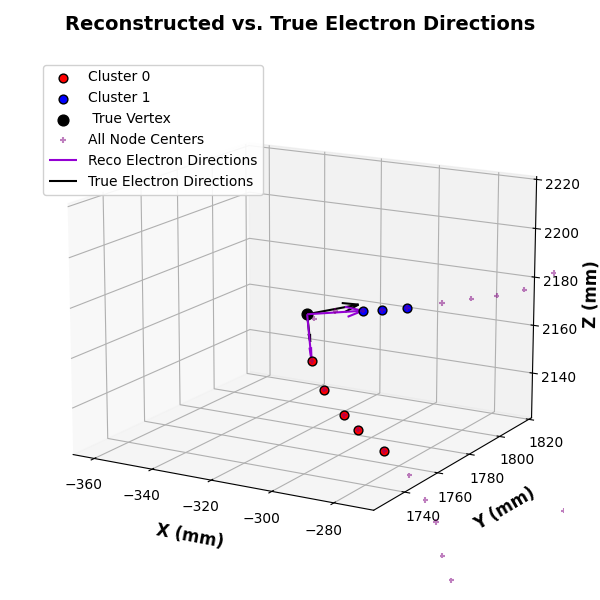

[{'endpoint': [-312.7298583984375, 1766.400634765625, 2154.7890625],
  'direction': [4.700042724609375, -5.535888671875, -16.357666015625]},
 {'endpoint': [-294.6982727050781, 1764.4901123046875, 2178.90869140625],
  'direction': [22.73162841796875, -7.4464111328125, 7.761962890625]}]

In [79]:
%matplotlib widget
get_reco_e_vectors(hits_df, part_df, eid, 10, diffusion, pressure, z_shift, vertex=vertex, plot=True, smeared=False)

### Reco Data (From Smeared Vertex)

In [20]:
def add_smear(part_df, eid, smear):
    vertex = get_vertex(part_df, eid)
        
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
                    
    r = smear
    
    x_new = vertex[0] + r * np.sin(theta) * np.cos(phi)
    y_new = vertex[1] + r * np.sin(theta) * np.sin(phi)
    z_new = vertex[2] + r * np.cos(theta)
    
    vertex_smeared = np.array([x_new, y_new, z_new])

    return vertex_smeared

### Testing json output files

In [22]:
nodiff_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/event_data/events_full_range_nodiff_1.jsonl", lines=True)
five_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/event_data/events_full_range_5.0percent_1.jsonl", lines=True)
zero_one_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/event_data/events_full_range_0.1percent_1.jsonl", lines=True)

nodiff_full_df.head()

,file,event_id,vertex,axis_limits,energies,vectors_true,cos12_true,vectors_reco,cos12_reco,vertex_1mm,...,cos12_2mm,vertex_3mm,vectors_3mm,cos12_3mm,vertex_4mm,vectors_4mm,cos12_4mm,vertex_5mm,vectors_5mm,cos12_5mm
0,events_full_range_nexus_149_7975749.h5,30000,"[2277.49609375, 581.3289794921875, 1946.750366...","{'xy': {'xlim': [2156.676062011719, 2571.82857...","[0.6562948822975151, 1.801699042320251]","[{'endpoint': [2277.871213916382, 581.93806974...",0.674890,"[{'endpoint': [2280.212646484375, 561.06323242...",0.391814,"[2278.3222930992406, 580.9854504446761, 1947.1...",...,0.483922,"[2276.5421892837626, 579.5633226484746, 1944.5...","[{'endpoint': [2280.212646484375, 561.06323242...",0.213880,"[2281.13766955602, 582.6136075139251, 1945.706...","[{'endpoint': [2280.212646484375, 561.06323242...",0.599928,"[2281.86018774851, 579.8077662131591, 1944.842...","[{'endpoint': [2280.212646484375, 561.06323242...",0.460307
1,events_full_range_nexus_149_7975749.h5,30001,"[437.98175048828125, 113.74400329589844, -1895...","{'xy': {'xlim': [-31.40203263759613, 766.81442...","[0.7035524249076841, 1.754457592964172]","[{'endpoint': [437.1174335329456, 113.91678268...",0.446982,"[{'endpoint': [423.4703674316406, 115.54029083...",0.033870,"[437.1738907531452, 113.82472091235853, -1895....",...,-0.107012,"[435.2160306820607, 114.79263823962589, -1895....","[{'endpoint': [438.71575927734375, 108.0336608...",0.126063,"[435.2944324135393, 110.78318386764711, -1895....","[{'endpoint': [423.4703674316406, 115.54029083...",-0.148800,"[442.5306823283901, 115.75185421354816, -1894....","[{'endpoint': [423.4703674316406, 115.54029083...",0.558095
2,events_full_range_nexus_149_7975749.h5,30002,"[-314.40911865234375, -2479.14501953125, 528.8...","{'xy': {'xlim': [-995.2144231796265, 3.1928281...","[0.745990276336669, 1.7120106220245361]","[{'endpoint': [-314.49658862282956, -2478.1782...",-0.038172,"[{'endpoint': [-322.2978515625, -2480.89819335...",0.021493,"[-313.6953387451307, -2479.826427864448, 528.7...",...,-0.058748,"[-317.2722429560114, -2479.223813598275, 529.7...","[{'endpoint': [-332.41583251953125, -2479.9990...",0.021328,"[-316.4204888080566, -2475.695191871962, 528.6...","[{'endpoint': [-313.8493347167969, -2454.26879...",-0.487150,"[-313.0554708369876, -2482.9023156764274, 531....","[{'endpoint': [-322.2978515625, -2480.89819335...",0.471850
3,events_full_range_nexus_149_7975749.h5,30003,"[-1832.31640625, 454.6137390136719, -731.60992...","{'xy': {'xlim': [-1853.4189697265624, -1500.10...","[0.7247740030288691, 1.7332178354263301]","[{'endpoint': [-1831.3590507532017, 454.543528...",0.460803,"[{'endpoint': [-1817.628662109375, 454.5359497...",0.314414,"[-1831.9331472875347, 455.103595578417, -732.3...",...,0.411083,"[-1832.0207125186992, 452.1224785899936, -729....","[{'endpoint': [-1828.7711181640625, 439.871002...",0.143717,"[-1833.5294037837268, 454.73489721331197, -735...","[{'endpoint': [-1828.7711181640625, 439.871002...",0.478352,"[-1836.0382978203672, 451.6454935347233, -733....","[{'endpoint': [-1828.7711181640625, 439.871002...",0.471297
4,events_full_range_nexus_149_7975749.h5,30004,"[1113.5433349609375, 1853.899658203125, -1770....","{'xy': {'xlim': [95.55943603515624, 1255.83948...","[0.6090482473373411, 1.8489525318145752]","[{'endpoint': [1113.4218350988813, 1852.915729...",-0.234450,"[{'endpoint': [1125.0521240234375, 1853.192504...",0.032586,"[1114.4167421242341, 1853.673886098063, -1771....",...,0.085380,"[1113.371880176304, 1853.0007466532427, -1773....","[{'endpoint': [1125.0521240234375, 1853.192504...",0.125975,"[1113.9029314371803, 1849.9471111237567, -1770...","[{'endpoint': [1125.0521240234375, 1853.192504...",-0.338837,"[1109.7346109021398, 1856.4970963753804, -1768...","[{'endpoint': [1125.0521240234375, 1853.192504...",0.351742


In [23]:
print(len(nodiff_full_df))
print(len(five_full_df))
print(len(zero_one_full_df))

114170
114170
114170


## Plots

### Angle Difference

#### Functions

In [24]:
def plot_diff_smear(df, smears, bins, title):
    bins_array = np.linspace(-5, 5, bins)
    n = len(smears) + 1  # +1 for true vertex
    cmap = plt.get_cmap("viridis")
    colors = [cmap(i / (n - 1)) for i in range(n)]
    plt.figure(figsize=(6,6))

    for idx, smear in enumerate(smears):
        smear_angle_diff = df[f"cos12_true"] - df[f"cos12_{smear}mm"]
        plt.hist(smear_angle_diff, bins=bins_array, color=colors[idx], histtype="step", label=f"{smear}mm smear")

    angle_res = (df[f"cos12_true"] - df[f"cos12_reco"])
    plt.hist(angle_res, bins=bins_array, color="black", histtype="step", linestyle="--", label="true vertex")

    plt.xlim(-2, 2)
    plt.xlabel("reco - true")
    plt.ylabel("events")
    plt.legend()
    plt.title(title)
    plt.show()

In [25]:
def compare_diff(dfs, df_labels, smear, bins, title):
    bins_array = np.linspace(-5, 5, bins)
    n = len(dfs)
    cmap = plt.get_cmap("viridis")
    colors = [cmap(i / (n - 1)) for i in range(n)]
    plt.figure(figsize=(6,6))

    for idx, (df, label) in enumerate(zip(dfs, df_labels)):
        cos12_true = df["cos12_true"]
        if smear == "none":
            cos12_reco = df["cos12_reco"]
        else:
            cos12_reco = df[f"cos12_{smear}mm"]
        smear_angle_diff = cos12_reco - cos12_true
        plt.hist(smear_angle_diff, bins=bins_array, color=colors[idx], histtype="step", label=label)

    plt.xlim(-2, 2)
    plt.xlabel("reco - true")
    plt.ylabel("events")
    plt.legend()
    plt.title(title)
    plt.show()

#### Difference (smear)

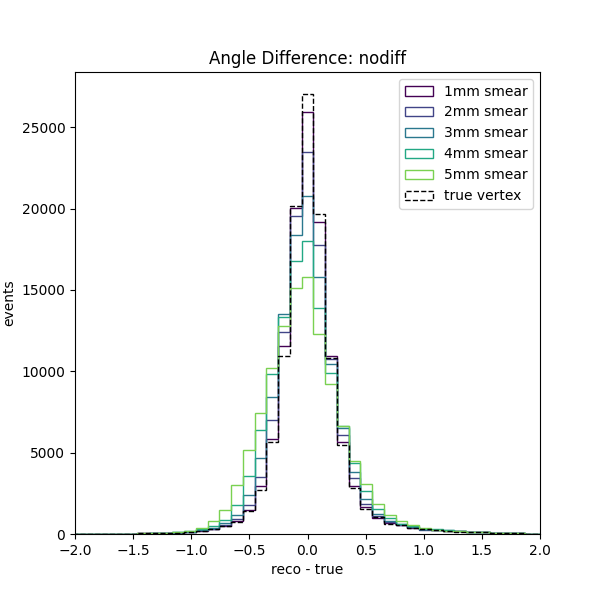

In [26]:
plot_diff_smear(nodiff_full_df, [1,2,3,4,5], 100, "Angle Difference: nodiff")

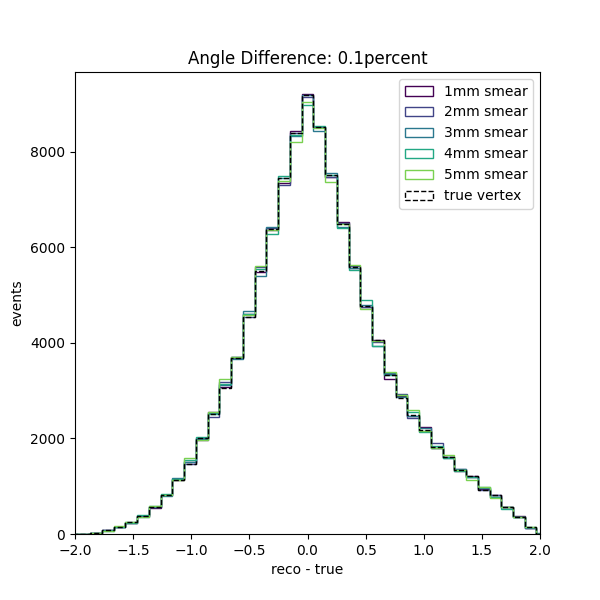

In [27]:
plot_diff_smear(zero_one_full_df, [1,2,3,4,5], 100, "Angle Difference: 0.1percent")

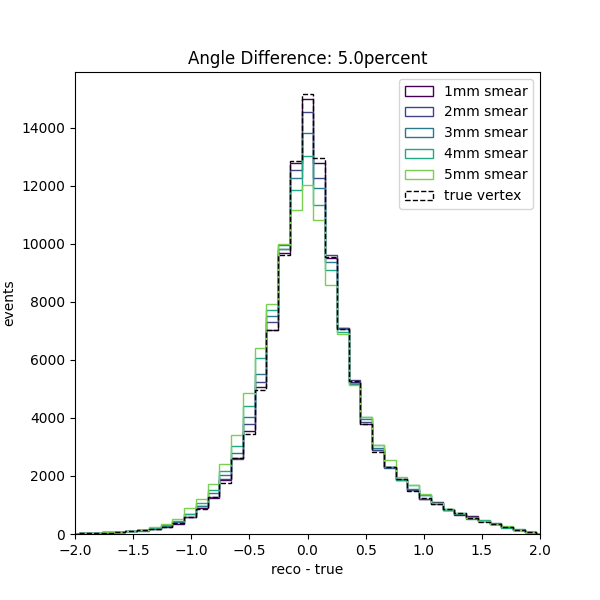

In [28]:
plot_diff_smear(five_full_df, [1,2,3,4,5], 100, "Angle Difference: 5.0percent")

#### Difference (diffusion)

In [29]:
diffusions = [nodiff_full_df, five_full_df, zero_one_full_df]
diffusion_labels = ["nodiff", "5.0percent", "0.1percent"]

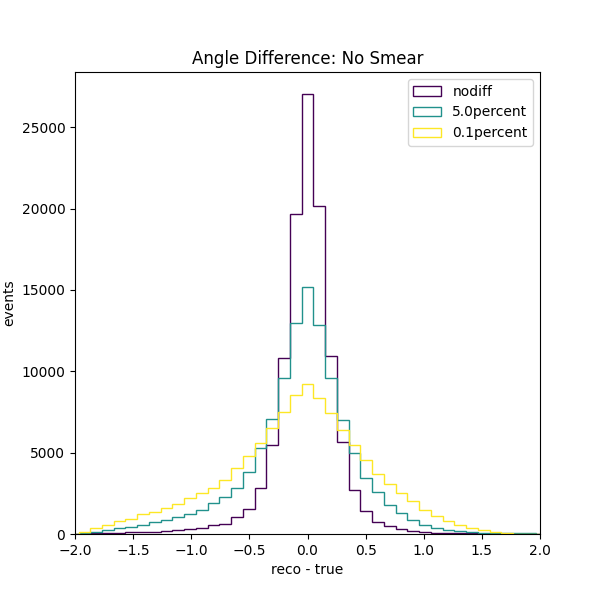

In [30]:
compare_diff(diffusions, diffusion_labels, "none", 100, "Angle Difference: No Smear")

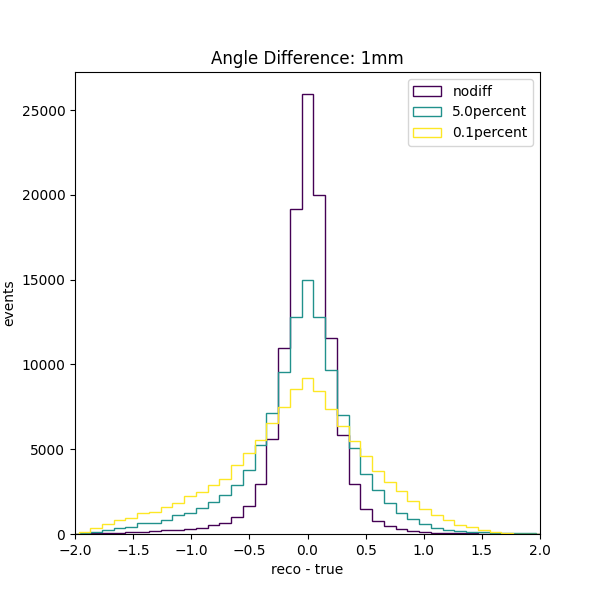

In [31]:
compare_diff(diffusions, diffusion_labels, 1, 100, "Angle Difference: 1mm")

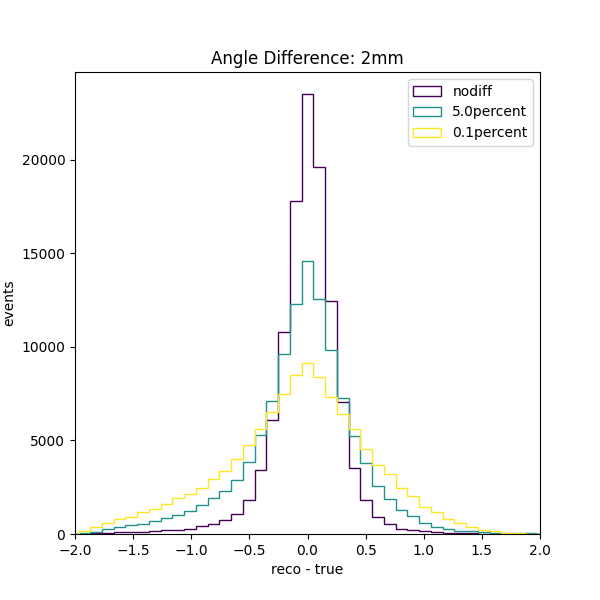

In [32]:
compare_diff(diffusions, diffusion_labels, 2, 100, "Angle Difference: 2mm")

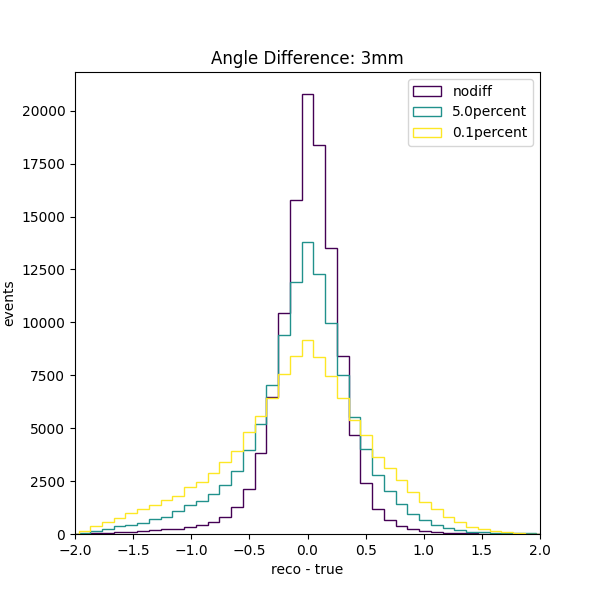

In [33]:
compare_diff(diffusions, diffusion_labels, 3, 100, "Angle Difference: 3mm")

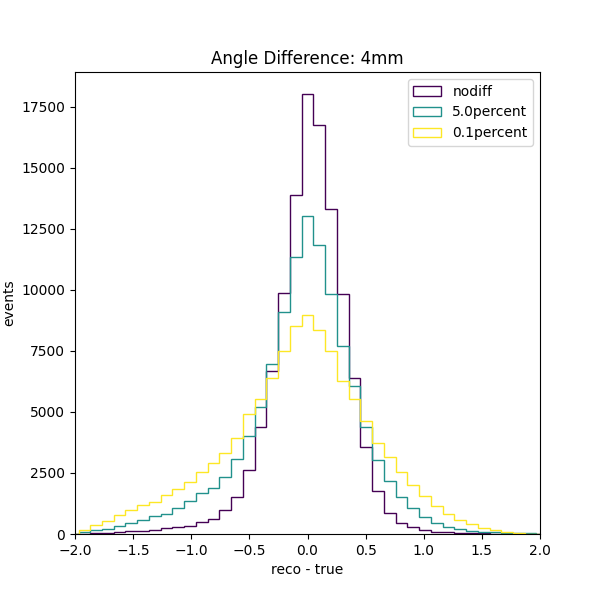

In [34]:
compare_diff(diffusions, diffusion_labels, 4, 100, "Angle Difference: 4mm")

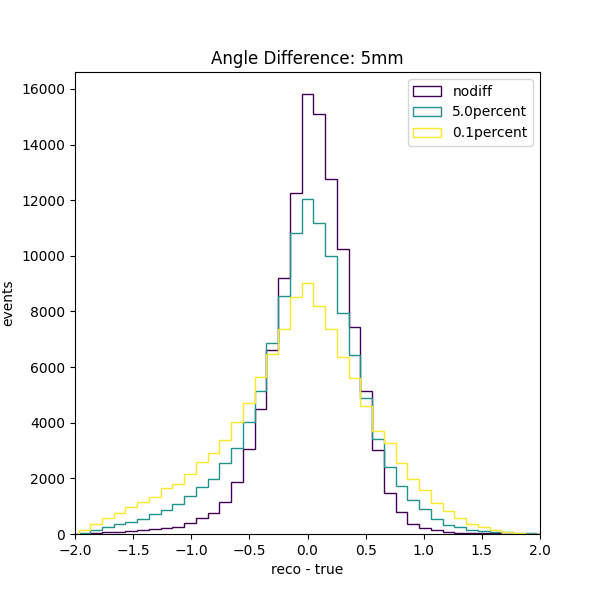

In [35]:
compare_diff(diffusions, diffusion_labels, 5, 100, "Angle Difference: 5mm")

### Asymmetry

In [36]:
E11 = nodiff_full_df["energies"].str[0]
E21 = nodiff_full_df["energies"].str[1]

nodiff_full_df["asymmetry"] = (E11 - E21) / (E11 + E21)

E12 = zero_one_full_df["energies"].str[0]
E22 = zero_one_full_df["energies"].str[1]

zero_one_full_df["asymmetry"] = (E12 - E22) / (E12 + E22)

E13 = five_full_df["energies"].str[0]
E23 = five_full_df["energies"].str[1]

five_full_df["asymmetry"] = (E13 - E23) / (E13 + E23)

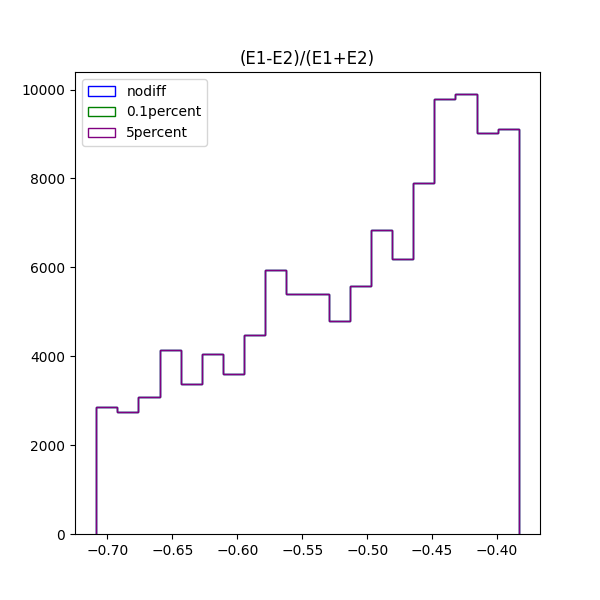

In [37]:
plt.figure(figsize=(6,6))
plt.hist(nodiff_full_df["asymmetry"], label="nodiff", color="blue", histtype="step", bins=20)
plt.hist(zero_one_full_df["asymmetry"], label="0.1percent", color="green", histtype="step", bins=20)
plt.hist(five_full_df["asymmetry"], label="5percent", color="purple", histtype="step", bins=20)
plt.title("(E1-E2)/(E1+E2)")
plt.legend()
plt.show()